# ResNet-18 - Image-Only Fraud Detection

ResNet-18 baseline for binary fraud classification on the multimodal image dataset.

**Experiment 1**: Unweighted loss (baseline - no imbalance correction)

**Experiment 2**: Weighted loss (pos_weight correction)

Threshold selection: **minimum expected cost** on the validation set
(FN × $50,000 + FP × $500) - identical to tabular notebooks 11 and 12.


In [1]:
import sys, random, torch
from pathlib import Path
import pandas as pd

sys.path.insert(0, r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src")

from image_baseline_utils import (
    build_model, unfreeze_backbone, fit_model,
    predict_probs, build_train_transform, build_val_transform,
)
from mm_image_utils import load_mm_splits, build_mm_dataloaders, make_loss_fn
from torch import nn

def set_seed(seed: int) -> None:
    random.seed(seed); __import__("numpy").random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Random seed: {SEED}")
print(f"Device     : {device}")


Random seed: 42
Device     : cpu


In [2]:
PROJECT_ROOT = Path().resolve().parent
DATA_DIR     = PROJECT_ROOT / "data" / "processed"
RESULTS_BASE = PROJECT_ROOT / "notebook" / "results" / "mm_image_resnet18"

TRAIN_CSV = DATA_DIR / "mm_train_mixed_all_group_test.csv"
VAL_CSV   = DATA_DIR / "mm_val_mixed_all_group_test.csv"
TEST_CSV  = DATA_DIR / "mm_test_mixed_all_group_test.csv"

BATCH_SIZE      = 32
NUM_WORKERS     = 0
STAGE1_EPOCHS   = 5;   STAGE1_LR   = 1e-3;  STAGE1_PATIENCE = 5
STAGE2_EPOCHS   = 20;  BACKBONE_LR = 1e-5;  HEAD_LR         = 1e-4
STAGE2_PATIENCE = 6
DROPOUT         = 0.3

EXP_DIRS = {
    "A_unweighted": RESULTS_BASE / "B_unweighted",
    "B_weighted":   RESULTS_BASE / "A_weighted",
}
for d in EXP_DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Results base:", RESULTS_BASE)


Project root: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis
Results base: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_image_resnet18


# Image-only baseline


In [3]:
train_df, val_df, test_df = load_mm_splits(TRAIN_CSV, VAL_CSV, TEST_CSV)

train_loader, val_loader, test_loader = build_mm_dataloaders(
    train_df, val_df, test_df,
    train_transform=build_train_transform(),
    val_transform=build_val_transform(),
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, use_sampler=False,
)
print(f"Batches — train:{len(train_loader)} val:{len(val_loader)} test:{len(test_loader)}")
print("\nTrain class counts:")
print(train_df["final_label"].value_counts())

LOSS_FNS = {
    "A_unweighted": nn.BCEWithLogitsLoss().to(device),
    "B_weighted":   make_loss_fn(train_df, device),
}


train: 7,182 rows | label 0:2,588 label 1:4,594 ratio 1:1.78
  combos: {'tab0_img0': 2588, 'tab0_img1': 1866, 'tab1_img0': 863, 'tab1_img1': 1865}
val: 1,508 rows | label 0:557 label 1:951 ratio 1:1.71
  combos: {'tab0_img0': 557, 'tab0_img1': 382, 'tab1_img0': 186, 'tab1_img1': 383}
test: 1,474 rows | label 0:554 label 1:920 ratio 1:1.66
  combos: {'tab0_img0': 554, 'tab0_img1': 368, 'tab1_img0': 185, 'tab1_img1': 367}
Batches — train:225 val:48 test:47

Train class counts:
final_label
1    4594
0    2588
Name: count, dtype: int64
  pos_weight = 0.563  (n_neg=2588, n_pos=4594)  [DOWN-weighting fraud (majority)]


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
)

FN_COST = 50_000
FP_COST = 500

def evaluate_image_model(y_true, y_prob, split_name="split", threshold=0.5):
    """Mirrors evaluate_model() from tabular utils."""
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "split": split_name,
        "accuracy":  float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true,    y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true,        y_pred, zero_division=0)),
        "roc_auc":   float(roc_auc_score(y_true, y_prob)),
        "pr_auc":    float(average_precision_score(y_true, y_prob)),
    }
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n=== {split_name.upper()} ===")
    for k, v in metrics.items():
        if k != "split": print(f"{k}: {v:.6f}")
    print("\nConfusion matrix:"); print(cm)
    return metrics, cm

def search_thresholds_image(y_true, y_prob,
                             thresholds=np.arange(0.10, 1.00, 0.05)):
    """Mirrors search_thresholds() from tabular utils."""
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        rows.append({
            "threshold":       round(float(t), 4),
            "precision":       float(precision_score(y_true, y_pred, zero_division=0)),
            "recall":          float(recall_score(y_true,    y_pred, zero_division=0)),
            "f1":              float(f1_score(y_true,        y_pred, zero_division=0)),
            "predicted_fraud": int(y_pred.sum()),
        })
    return pd.DataFrame(rows)

def compute_cost_table_image(threshold_results, y_val_true,
                              fn_cost=FN_COST, fp_cost=FP_COST):
    """Mirrors compute_cost_table() from tabular utils."""
    n_pos = int((y_val_true == 1).sum())
    n_neg = int((y_val_true == 0).sum())
    rows = []
    for _, row in threshold_results.iterrows():
        tp = round(row["recall"] * n_pos)
        fn = n_pos - tp
        fp = row["predicted_fraud"] - tp
        tn = n_neg - fp
        rows.append({
            "threshold": row["threshold"],
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "precision": row["precision"],
            "recall":    row["recall"],
            "f1":        row["f1"],
            "predicted_fraud": row["predicted_fraud"],
            "expected_cost":   int(fn * fn_cost + fp * fp_cost),
        })
    return pd.DataFrame(rows).sort_values("expected_cost").reset_index(drop=True)

def evaluate_image_with_threshold(y_true, y_prob, threshold):
    """Mirrors evaluate_with_threshold() from tabular utils."""
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    metrics = {
        "threshold": float(threshold),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true,    y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true,        y_pred, zero_division=0)),
    }
    print(f"\nTuned threshold: {threshold}")
    print(f"Precision: {metrics['precision']:.6f}")
    print(f"Recall:    {metrics['recall']:.6f}")
    print(f"F1:        {metrics['f1']:.6f}")
    print("\nConfusion matrix:"); print(cm)
    return metrics, cm

def compute_expected_cost_from_cm(cm, fn_cost=FN_COST, fp_cost=FP_COST):
    """Mirrors compute_expected_cost_from_cm() from tabular utils."""
    tn, fp, fn, tp = cm.ravel()
    return {"tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
            "expected_cost": int(fn * fn_cost + fp * fp_cost)}

def save_image_experiment_outputs(results_dir, test_y_true, test_y_prob,
                                   threshold_results, cost_df,
                                   tuned_metrics, tuned_cm,
                                   val_metrics, test_metrics, prefix):
    """Mirrors save_experiment_outputs() from tabular utils."""
    from pathlib import Path
    results_dir = Path(results_dir)
    pred_df = pd.DataFrame({"y_true": test_y_true, "y_prob": test_y_prob})
    pred_df["y_pred"] = (pred_df["y_prob"] >= tuned_metrics["threshold"]).astype(int)
    pred_df.to_csv(results_dir / "test_predictions.csv", index=False)
    threshold_results.to_csv(results_dir / f"{prefix}_threshold_results.csv", index=False)
    cost_df.to_csv(results_dir / f"{prefix}_cost_results.csv", index=False)
    pd.DataFrame([tuned_metrics]).to_csv(results_dir / f"{prefix}_tuned_metrics.csv", index=False)
    pd.DataFrame(tuned_cm, index=["true_0","true_1"],
                 columns=["pred_0","pred_1"]).to_csv(
        results_dir / f"{prefix}_tuned_cm.csv")
    pd.DataFrame([val_metrics, test_metrics]).to_csv(
        results_dir / f"{prefix}_metrics_summary.csv", index=False)

def plot_model_diagnostics_pretty(cm, threshold_results, cost_df, model_name,
                                   fn_cost=FN_COST, fp_cost=FP_COST, save_path=None):
    """Copied from notebooks 11 and 12 — identical function."""
    cm = np.asarray(cm).astype(int)
    threshold_df   = threshold_results.sort_values("threshold")
    cost_df_sorted = cost_df.sort_values("threshold")
    best_row            = cost_df.loc[cost_df["expected_cost"].idxmin()]
    best_threshold      = float(best_row["threshold"])
    best_validation_cost = float(best_row["expected_cost"])
    tn, fp, fn, tp = cm.ravel()
    test_expected_cost  = fn * fn_cost + fp * fp_cost

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)
    fig.patch.set_facecolor("white")

    ax = axes[0]
    cm_for_color = np.maximum(cm, 1)
    norm = LogNorm(vmin=1, vmax=cm_for_color.max())
    im = ax.imshow(cm_for_color, cmap="Blues", norm=norm)
    ax.set_title("Tuned test confusion matrix", fontsize=12, pad=12)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Legit","Fraud"]); ax.set_yticklabels(["Legit","Fraud"])
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    for i in range(2):
        for j in range(2):
            value = cm[i,j]
            rgba  = im.cmap(norm(cm_for_color[i,j]))
            lum   = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
            ax.text(j, i, f"{value:,}", ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color="white" if lum < 0.45 else "#08306b")
    for sp in ax.spines.values(): sp.set_visible(False)

    ax = axes[1]
    ax.plot(threshold_df["threshold"], threshold_df["precision"], linewidth=2.2, label="Precision")
    ax.plot(threshold_df["threshold"], threshold_df["recall"],    linewidth=2.2, label="Recall")
    ax.plot(threshold_df["threshold"], threshold_df["f1"],        linewidth=2.2, label="F1")
    ax.axvline(best_threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.7)
    ax.text(0.98, 0.95, f"Best threshold = {best_threshold:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=10,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
    ax.set_title("Validation metrics by threshold", fontsize=12, pad=12)
    ax.set_xlabel("Threshold"); ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.25); ax.legend(frameon=False, loc="lower left")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    ax = axes[2]
    ax.plot(cost_df_sorted["threshold"], cost_df_sorted["expected_cost"],
            linewidth=2.2, marker="o", markersize=4)
    ax.axvline(best_threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.7)
    ax.scatter(best_threshold, best_validation_cost, s=80, color="black", zorder=5)
    ax.annotate(f"Min cost: ${best_validation_cost/1_000_000:.2f}M",
                xy=(best_threshold, best_validation_cost), xytext=(18,18),
                textcoords="offset points", fontsize=10,
                arrowprops=dict(arrowstyle="->", linewidth=1, color="black"),
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.85))
    ax.set_title("Validation expected cost by threshold", fontsize=12, pad=12)
    ax.set_xlabel("Threshold"); ax.set_ylabel("Expected cost")
    ax.grid(True, alpha=0.25)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    fig.suptitle(
        f"{model_name} diagnostics | Tuned test cost: ${test_expected_cost/1_000_000:.2f}M",
        fontsize=15, fontweight="bold")
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

print("All helper functions defined.")


All helper functions defined.


## 1. ResNet-18 - without loss weighting

Standard BCEWithLogitsLoss with no class weight correction.
Baseline - equivalent to LR-none and XGB-none in notebooks 11 and 12.

In [5]:
results_dir = EXP_DIRS["A_unweighted"]
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "stage2_best.pt"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved 1. ResNet-18 — without loss weighting model...")
    model_unweighted = build_model(pretrained=False, freeze_backbone=False,
                               dropout=DROPOUT).to(device)
    model_unweighted.load_state_dict(torch.load(model_path, map_location=device))
    model_unweighted.eval()
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training 1. ResNet-18 — without loss weighting model...")
    model_unweighted = build_model(pretrained=True, freeze_backbone=True,
                               dropout=DROPOUT).to(device)
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model_unweighted.parameters()),
        lr=STAGE1_LR, weight_decay=1e-4)
    model_unweighted, h_s1 = fit_model(
        model=model_unweighted, train_loader=train_loader, val_loader=val_loader,
        loss_fn=LOSS_FNS["A_unweighted"], optimizer=opt1, device=device,
        epochs=STAGE1_EPOCHS, early_stopping_patience=STAGE1_PATIENCE,
        monitor_metric="val_roc_auc",
        model_save_path=results_dir / "stage1_best.pt",
    )
    unfreeze_backbone(model_unweighted)
    bp = [p for n, p in model_unweighted.named_parameters() if "fc" not in n]
    hp = list(model_unweighted.fc.parameters())
    opt2 = torch.optim.Adam(
        [{"params": bp, "lr": BACKBONE_LR},
         {"params": hp, "lr": HEAD_LR}], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
    model_unweighted, h_s2 = fit_model(
        model=model_unweighted, train_loader=train_loader, val_loader=val_loader,
        loss_fn=LOSS_FNS["A_unweighted"], optimizer=opt2, scheduler=sched,
        device=device, epochs=STAGE2_EPOCHS,
        early_stopping_patience=STAGE2_PATIENCE,
        monitor_metric="val_roc_auc",
        model_save_path=model_path,
    )
    hist = pd.concat([h_s1.assign(stage=1), h_s2.assign(stage=2)], ignore_index=True)
    hist["epoch_global"] = range(1, len(hist)+1)
    hist.to_csv(results_dir / "training_history.csv", index=False)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_image_resnet18\B_unweighted\stage2_best.pt
Model exists: True
Already trained. Loading saved 1. ResNet-18 — without loss weighting model...
Model loaded successfully.


In [6]:
val_y_unweighted, val_p_unweighted = predict_probs(model_unweighted, val_loader,  device)
test_y_unweighted,    test_p_unweighted  = predict_probs(model_unweighted, test_loader, device)

val_metrics_unweighted,  val_cm_unweighted  = evaluate_image_model(
    val_y_unweighted, val_p_unweighted, split_name="validation_unweighted")
test_metrics_unweighted, test_cm_unweighted = evaluate_image_model(
    test_y_unweighted,    test_p_unweighted,  split_name="test_unweighted")



=== VALIDATION_UNWEIGHTED ===
accuracy: 0.830239
precision: 0.883978
recall: 0.841220
f1: 0.862069
roc_auc: 0.878486
pr_auc: 0.936802

Confusion matrix:
[[452 105]
 [151 800]]

=== TEST_UNWEIGHTED ===
accuracy: 0.831750
precision: 0.894366
recall: 0.828261
f1: 0.860045
roc_auc: 0.885104
pr_auc: 0.938443

Confusion matrix:
[[464  90]
 [158 762]]


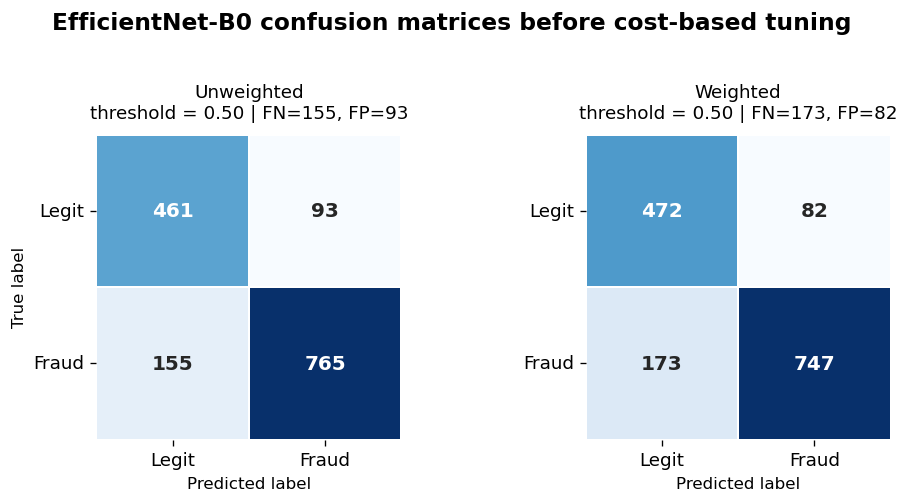

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm_default_unweighted = np.array([
    [461,  93],
    [155, 765],
])

cm_default_weighted = np.array([
    [472,  82],
    [173, 747],
])

fig, axes = plt.subplots(1, 2, figsize=(8.5, 4))

plots = [
    (cm_default_unweighted, "Unweighted", "threshold = 0.50"),
    (cm_default_weighted, "Weighted", "threshold = 0.50"),
]

for i, (ax, (cm, title_, subtitle)) in enumerate(zip(axes, plots)):
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        linewidths=1,
        linecolor="white",
        xticklabels=["Legit", "Fraud"],
        yticklabels=["Legit", "Fraud"],
        ax=ax,
        annot_kws={"fontsize": 12, "fontweight": "bold"}
    )

    ax.set_title(
        f"{title_}\n{subtitle} | FN={fn}, FP={fp}",
        fontsize=11,
        pad=10
    )

    ax.set_xlabel("Predicted label", fontsize=10)

    if i == 0:
        ax.set_ylabel("True label", fontsize=10)
    else:
        ax.set_ylabel("")

    ax.tick_params(axis="x", labelrotation=0)
    ax.tick_params(axis="y", labelrotation=0)

plt.suptitle(
    "EfficientNet-B0 confusion matrices before cost-based tuning",
    fontsize=14,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

### ResNet18 unweighted baseline results

The unweighted ResNet18 image-only model achieves stable performance on both validation and test sets. On the validation set, the model reaches an F1-score of 0.8621, while on the test set it achieves a very similar F1-score of 0.8600. This suggests that the model generalizes consistently and does not show a large drop from validation to test.

On the test set, precision is 0.8944 and recall is 0.8283. This means that most transactions predicted as fraud are actually fraud, but the model still misses some fraud cases. The confusion matrix shows that the model correctly detects 762 fraud cases, while missing 158. It also incorrectly flags 90 legitimate cases as fraud.

The ROC-AUC score is 0.8851 and the PR-AUC score is 0.9384. These results show that the model has useful image-based ranking ability, especially considering that it uses only image information.

The unweighted ResNet18 model learns meaningful visual fraud signals, but it is not sufficient on its own. It performs reasonably well, but it still misses a noticeable number of fraud cases, which suggests that image information should be combined with tabular data in the multimodal model.

### Cost-based threshold tuning for the unweighted ResNet18 model

In [7]:
threshold_results_unweighted = search_thresholds_image(val_y_unweighted, val_p_unweighted)
print(threshold_results_unweighted)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.632599  0.995794  0.773693             1497
1        0.15   0.649686  0.978970  0.781040             1433
2        0.20   0.685015  0.942166  0.793271             1308
3        0.25   0.764444  0.904311  0.828516             1125
4        0.30   0.830474  0.865405  0.847580              991
5        0.35   0.855497  0.859096  0.857293              955
6        0.40   0.867380  0.852787  0.860021              935
7        0.45   0.871629  0.849632  0.860490              927
8        0.50   0.883978  0.841220  0.862069              905
9        0.55   0.898053  0.824395  0.859649              873
10       0.60   0.910394  0.801262  0.852349              837
11       0.65   0.912883  0.782334  0.842582              815
12       0.70   0.920949  0.735016  0.817544              759
13       0.75   0.935953  0.676130  0.785104              687
14       0.80   0.950161  0.621451  0.751430              622
15      

In [8]:
cost_df_unweighted = compute_cost_table_image(threshold_results_unweighted, val_y_unweighted)
print(cost_df_unweighted.head())


   threshold   tp     fp   fn     tn  precision    recall        f1  \
0       0.10  947  550.0    4    7.0   0.632599  0.995794  0.773693   
1       0.15  931  502.0   20   55.0   0.649686  0.978970  0.781040   
2       0.20  896  412.0   55  145.0   0.685015  0.942166  0.793271   
3       0.25  860  265.0   91  292.0   0.764444  0.904311  0.828516   
4       0.30  823  168.0  128  389.0   0.830474  0.865405  0.847580   

   predicted_fraud  expected_cost  
0           1497.0         475000  
1           1433.0        1251000  
2           1308.0        2956000  
3           1125.0        4682500  
4            991.0        6484000  




Threshold tuning was applied to the unweighted ResNet18 model using the validation set. The table shows that the lowest expected validation cost is achieved at threshold 0.10.

At this threshold, the model detects 947 fraud cases and misses only 4. However, it also produces 550 false positives. Even though this creates many false alarms, the expected cost is still the lowest because false negatives are much more expensive than false positives.

The expected validation cost at threshold 0.10 is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 4 × $50,000 + 550 × $500  
Expected cost = $200,000 + $275,000  
Expected cost = $475,000

This threshold gives very high recall of 0.9958, meaning that the model detects almost all fraud cases in the validation set. Precision is lower at 0.6326 because many legitimate cases are also flagged as fraud.

Overall, cost-based tuning selects a much lower threshold than F1-based tuning. This is because the cost function strongly penalizes missed fraud cases. For cost-sensitive fraud detection, threshold 0.10 is therefore the preferred threshold for the unweighted ResNet18 model.

In [9]:
default_validation_cost = compute_expected_cost_from_cm(val_cm_unweighted)["expected_cost"]
best_validation_cost    = cost_df_unweighted.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $7,602,500
Best tuned validation cost: $475,000
Cost reduction:             $7,127,500


In [10]:
best_threshold_unweighted = float(cost_df_unweighted.iloc[0]["threshold"])
best_threshold_unweighted


0.1

### Tuned threshold results for ResNet-18 unweighted

After selecting the threshold on the validation set, the same threshold is applied to the held-out test set.

In [11]:
tuned_metrics_unweighted, tuned_cm_unweighted = evaluate_image_with_threshold(
    test_y_unweighted, test_p_unweighted, best_threshold_unweighted)
cost_summary_unweighted = compute_expected_cost_from_cm(tuned_cm_unweighted)
print(cost_summary_unweighted)



Tuned threshold: 0.1
Precision: 0.627907
Recall:    0.997826
F1:        0.770781

Confusion matrix:
[[ 10 544]
 [  2 918]]
{'tp': 918, 'fp': 544, 'fn': 2, 'tn': 10, 'expected_cost': 372000}


After cost-based threshold tuning, the selected threshold for the unweighted ResNet18 model was 0.10. This is much lower than the F1-based threshold, because the cost function strongly penalizes missed fraud cases.

On the test set, the cost-tuned model achieved a precision of 0.6279, recall of 0.9978, and F1-score of 0.7708. This means that the model detects almost all fraud cases, but it also produces many false positives.

The confusion matrix shows that the model correctly detects 918 out of 920 fraud cases and misses only 2. However, it incorrectly flags 544 legitimate cases as fraud and correctly identifies only 10 legitimate cases.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 2 × $50,000 + 544 × $500  
Expected cost = $100,000 + $272,000  
Expected cost = $372,000

Overall, cost-based threshold tuning greatly reduces false negatives, which lowers the expected cost. However, the model becomes extremely aggressive and classifies most legitimate cases as fraud. This shows that the image-only ResNet can reduce cost by catching almost all fraud cases, but it does so at the expense of many false positives.

In [12]:
save_image_experiment_outputs(
    results_dir=results_dir,
    test_y_true=test_y_unweighted, test_y_prob=test_p_unweighted,
    threshold_results=threshold_results_unweighted, cost_df=cost_df_unweighted,
    tuned_metrics=tuned_metrics_unweighted, tuned_cm=tuned_cm_unweighted,
    val_metrics=val_metrics_unweighted, test_metrics=test_metrics_unweighted,
    prefix="unweighted",
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_image_resnet18\B_unweighted


In [13]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['stage1_best.pt',
 'stage2_best.pt',
 'subgroup_combo_type.csv',
 'test_metrics.json',
 'test_predictions.csv',
 'threshold_summary.json',
 'threshold_sweep.csv',
 'training_history.csv',
 'unweighted_cost_results.csv',
 'unweighted_metrics_summary.csv',
 'unweighted_threshold_results.csv',
 'unweighted_tuned_cm.csv',
 'unweighted_tuned_metrics.csv']

## 2. ResNet-18 - with pos_weight loss weighting

BCEWithLogitsLoss with pos_weight = n_neg / n_pos computed from training data.
pos_weight < 1 down-weights fraud (majority class in this dataset).

In [14]:
results_dir = EXP_DIRS["B_weighted"]
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "stage2_best.pt"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved 2. ResNet-18 — with pos_weight loss weighting model...")
    model_weighted = build_model(pretrained=False, freeze_backbone=False,
                               dropout=DROPOUT).to(device)
    model_weighted.load_state_dict(torch.load(model_path, map_location=device))
    model_weighted.eval()
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training 2. ResNet-18 — with pos_weight loss weighting model...")
    model_weighted = build_model(pretrained=True, freeze_backbone=True,
                               dropout=DROPOUT).to(device)
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model_weighted.parameters()),
        lr=STAGE1_LR, weight_decay=1e-4)
    model_weighted, h_s1 = fit_model(
        model=model_weighted, train_loader=train_loader, val_loader=val_loader,
        loss_fn=LOSS_FNS["B_weighted"], optimizer=opt1, device=device,
        epochs=STAGE1_EPOCHS, early_stopping_patience=STAGE1_PATIENCE,
        monitor_metric="val_roc_auc",
        model_save_path=results_dir / "stage1_best.pt",
    )
    unfreeze_backbone(model_weighted)
    bp = [p for n, p in model_weighted.named_parameters() if "fc" not in n]
    hp = list(model_weighted.fc.parameters())
    opt2 = torch.optim.Adam(
        [{"params": bp, "lr": BACKBONE_LR},
         {"params": hp, "lr": HEAD_LR}], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
    model_weighted, h_s2 = fit_model(
        model=model_weighted, train_loader=train_loader, val_loader=val_loader,
        loss_fn=LOSS_FNS["B_weighted"], optimizer=opt2, scheduler=sched,
        device=device, epochs=STAGE2_EPOCHS,
        early_stopping_patience=STAGE2_PATIENCE,
        monitor_metric="val_roc_auc",
        model_save_path=model_path,
    )
    hist = pd.concat([h_s1.assign(stage=1), h_s2.assign(stage=2)], ignore_index=True)
    hist["epoch_global"] = range(1, len(hist)+1)
    hist.to_csv(results_dir / "training_history.csv", index=False)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_image_resnet18\A_weighted\stage2_best.pt
Model exists: True
Already trained. Loading saved 2. ResNet-18 — with pos_weight loss weighting model...
Model loaded successfully.


In [15]:
val_y_weighted, val_p_weighted = predict_probs(model_weighted, val_loader,  device)
test_y_weighted,    test_p_weighted  = predict_probs(model_weighted, test_loader, device)

val_metrics_weighted,  val_cm_weighted  = evaluate_image_model(
    val_y_weighted, val_p_weighted, split_name="validation_weighted")
test_metrics_weighted, test_cm_weighted = evaluate_image_model(
    test_y_weighted,    test_p_weighted,  split_name="test_weighted")



=== VALIDATION_WEIGHTED ===
accuracy: 0.816976
precision: 0.901308
recall: 0.797056
f1: 0.845982
roc_auc: 0.876130
pr_auc: 0.935574

Confusion matrix:
[[474  83]
 [193 758]]

=== TEST_WEIGHTED ===
accuracy: 0.817503
precision: 0.909434
recall: 0.785870
f1: 0.843149
roc_auc: 0.880256
pr_auc: 0.935706

Confusion matrix:
[[482  72]
 [197 723]]


### ResNet18 weighted baseline results

The weighted ResNet18 image-only model shows stable performance on validation and test data. On the validation set, it achieves an F1-score of 0.8460, while on the test set the F1-score is 0.8431. This suggests that the model generalizes consistently.

On the test set, precision is 0.9094 and recall is 0.7859. This means that when the model predicts fraud, it is usually correct. However, it still misses a noticeable number of fraud cases.

The confusion matrix shows that the model correctly detects 723 fraud cases and misses 197. It also incorrectly flags 72 legitimate cases as fraud and correctly classifies 482 legitimate cases.

The ROC-AUC is 0.8803 and PR-AUC is 0.9357, which shows that the model has useful image-based ranking ability. However, compared with the unweighted ResNet18 model, the weighted model has slightly lower recall and F1-score, although it produces fewer false positives.

The weighted ResNet18 model is more conservative than the unweighted model. It makes fewer false positive errors, but it misses more fraud cases. Since fraud detection is cost-sensitive, this may not be the best trade-off.

### Cost-based threshold tuning for the weighted ResNet18 model

In [16]:
threshold_results_weighted = search_thresholds_image(val_y_weighted, val_p_weighted)
print(threshold_results_weighted)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.665208  0.958991  0.785530             1371
1        0.15   0.735021  0.915878  0.815543             1185
2        0.20   0.821114  0.883281  0.851064             1023
3        0.25   0.863492  0.858044  0.860759              945
4        0.30   0.874459  0.849632  0.861867              924
5        0.35   0.883131  0.842271  0.862217              907
6        0.40   0.892290  0.827550  0.858702              882
7        0.45   0.895833  0.813880  0.852893              864
8        0.50   0.901308  0.797056  0.845982              841
9        0.55   0.910448  0.769716  0.834188              804
10       0.60   0.921543  0.728707  0.813858              752
11       0.65   0.930435  0.675079  0.782450              690
12       0.70   0.950161  0.621451  0.751430              622
13       0.75   0.957295  0.565720  0.711170              562
14       0.80   0.964286  0.539432  0.691841              532
15      

In [17]:
cost_df_weighted = compute_cost_table_image(threshold_results_weighted, val_y_weighted)
print(cost_df_weighted.head())


   threshold   tp     fp   fn     tn  precision    recall        f1  \
0       0.10  912  459.0   39   98.0   0.665208  0.958991  0.785530   
1       0.15  871  314.0   80  243.0   0.735021  0.915878  0.815543   
2       0.20  840  183.0  111  374.0   0.821114  0.883281  0.851064   
3       0.25  816  129.0  135  428.0   0.863492  0.858044  0.860759   
4       0.30  808  116.0  143  441.0   0.874459  0.849632  0.861867   

   predicted_fraud  expected_cost  
0           1371.0        2179500  
1           1185.0        4157000  
2           1023.0        5641500  
3            945.0        6814500  
4            924.0        7208000  




Threshold tuning was applied to the weighted ResNet18 model using the validation set. The lowest expected validation cost is achieved at threshold 0.10.

At this threshold, the model detects 912 fraud cases and misses 39. It also produces 459 false positives. This gives an expected validation cost of $2,179,500.

The expected validation cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 39 × $50,000 + 459 × $500  
Expected cost = $1,950,000 + $229,500  
Expected cost = $2,179,500

At threshold 0.10, recall is high at 0.9590, but precision drops to 0.6652. This means the model catches many more fraud cases, but it also flags more legitimate cases as fraud.

Cost-based tuning chooses a much lower threshold than the default threshold. This happens because the cost function strongly penalizes false negatives. However, compared with the unweighted ResNet18 model, the weighted model still has a higher validation cost because it misses more fraud cases.

In [18]:
default_validation_cost = compute_expected_cost_from_cm(val_cm_weighted)["expected_cost"]
best_validation_cost    = cost_df_weighted.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $9,691,500
Best tuned validation cost: $2,179,500
Cost reduction:             $7,512,000


### Cost-tuned test results for the weighted ResNet18 model

In [19]:
best_threshold_weighted = float(cost_df_weighted.iloc[0]["threshold"])
best_threshold_weighted


0.1

In [20]:
tuned_metrics_weighted, tuned_cm_weighted = evaluate_image_with_threshold(
    test_y_weighted, test_p_weighted, best_threshold_weighted)
cost_summary_weighted = compute_expected_cost_from_cm(tuned_cm_weighted)
print(cost_summary_weighted)



Tuned threshold: 0.1
Precision: 0.672700
Recall:    0.969565
F1:        0.794301

Confusion matrix:
[[120 434]
 [ 28 892]]
{'tp': 892, 'fp': 434, 'fn': 28, 'tn': 120, 'expected_cost': 1617000}




After cost-based threshold tuning, the selected threshold for the weighted ResNet18 model was 0.10. This lower threshold makes the model more sensitive to fraud, which helps reduce false negatives.

On the test set, the model achieved precision of 0.6727, recall of 0.9696, and F1-score of 0.7943. This means that the model detects most fraud cases, but it also produces many false positives.

The confusion matrix shows that the model correctly detects 892 out of 920 fraud cases and misses 28. It also incorrectly flags 434 legitimate cases as fraud, while correctly classifying 120 legitimate cases.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 28 × $50,000 + 434 × $500  
Expected cost = $1,400,000 + $217,000  
Expected cost = $1,617,000



In [21]:
save_image_experiment_outputs(
    results_dir=results_dir,
    test_y_true=test_y_weighted, test_y_prob=test_p_weighted,
    threshold_results=threshold_results_weighted, cost_df=cost_df_weighted,
    tuned_metrics=tuned_metrics_weighted, tuned_cm=tuned_cm_weighted,
    val_metrics=val_metrics_weighted, test_metrics=test_metrics_weighted,
    prefix="weighted",
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_image_resnet18\A_weighted


In [22]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['stage1_best.pt',
 'stage2_best.pt',
 'subgroup_combo_type.csv',
 'test_metrics.json',
 'test_predictions.csv',
 'threshold_summary.json',
 'threshold_sweep.csv',
 'training_history.csv',
 'weighted_cost_results.csv',
 'weighted_metrics_summary.csv',
 'weighted_threshold_results.csv',
 'weighted_tuned_cm.csv',
 'weighted_tuned_metrics.csv']

## 3. Comparison of loss variants

The table below compares the two ResNet-18 variants.


In [23]:
comparison_df = pd.DataFrame([
    {
        "model":               "unweighted",
        "val_f1":              val_metrics_unweighted["f1"],
        "val_roc_auc":         val_metrics_unweighted["roc_auc"],
        "val_pr_auc":          val_metrics_unweighted["pr_auc"],
        "test_f1":             test_metrics_unweighted["f1"],
        "test_roc_auc":        test_metrics_unweighted["roc_auc"],
        "test_pr_auc":         test_metrics_unweighted["pr_auc"],
        "best_threshold":      best_threshold_unweighted,
        "tuned_test_precision":tuned_metrics_unweighted["precision"],
        "tuned_test_recall":   tuned_metrics_unweighted["recall"],
        "tuned_test_f1":       tuned_metrics_unweighted["f1"],
        "tuned_expected_cost": cost_summary_unweighted["expected_cost"],
    },
    {
        "model":               "weighted",
        "val_f1":              val_metrics_weighted["f1"],
        "val_roc_auc":         val_metrics_weighted["roc_auc"],
        "val_pr_auc":          val_metrics_weighted["pr_auc"],
        "test_f1":             test_metrics_weighted["f1"],
        "test_roc_auc":        test_metrics_weighted["roc_auc"],
        "test_pr_auc":         test_metrics_weighted["pr_auc"],
        "best_threshold":      best_threshold_weighted,
        "tuned_test_precision":tuned_metrics_weighted["precision"],
        "tuned_test_recall":   tuned_metrics_weighted["recall"],
        "tuned_test_f1":       tuned_metrics_weighted["f1"],
        "tuned_expected_cost": cost_summary_weighted["expected_cost"],
    },
])
print(comparison_df)


        model    val_f1  val_roc_auc  val_pr_auc   test_f1  test_roc_auc  \
0  unweighted  0.862069     0.878486    0.936802  0.860045      0.885104   
1    weighted  0.845982     0.876130    0.935574  0.843149      0.880256   

   test_pr_auc  best_threshold  tuned_test_precision  tuned_test_recall  \
0     0.938443             0.1              0.627907           0.997826   
1     0.935706             0.1              0.672700           0.969565   

   tuned_test_f1  tuned_expected_cost  
0       0.770781               372000  
1       0.794301              1617000  


In [24]:
comparison_df.sort_values("tuned_expected_cost")[
    ["model","best_threshold","tuned_test_precision",
     "tuned_test_recall","tuned_test_f1","tuned_expected_cost"]
]


,model,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,unweighted,0.1,0.627907,0.997826,0.770781,372000
1,weighted,0.1,0.672700,0.969565,0.794301,1617000


The comparison shows whether loss weighting improves performance under cost-sensitive evaluation.

Among the image-only ResNet18 variants, the unweighted model performed best from a cost-sensitive perspective. Although the weighted model achieved a slightly higher tuned F1-score, the unweighted model had higher recall and a much lower expected cost. After cost-based threshold tuning, the unweighted model missed only 2 fraud cases and achieved an expected cost of $372,000, compared with $1,617,000 for the weighted model. Therefore, the unweighted ResNet18 model was selected as the final image-only baseline.

## Class imbalance plot

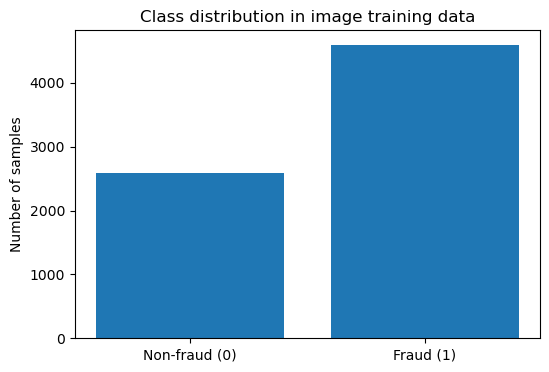

In [25]:
class_counts = train_df["final_label"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(["Non-fraud (0)", "Fraud (1)"], class_counts.values)
plt.title("Class distribution in image training data")
plt.ylabel("Number of samples")
plt.show()


## Comparison bar chart for the 2 variants

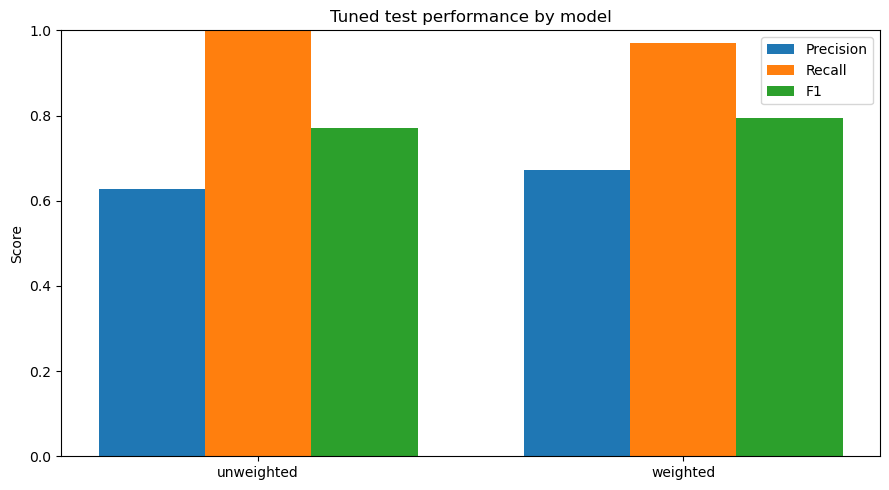

In [26]:
import numpy as np

metrics_plot  = ["tuned_test_precision","tuned_test_recall","tuned_test_f1"]
metric_labels = ["Precision","Recall","F1"]

x     = np.arange(len(comparison_df["model"]))
width = 0.25

plt.figure(figsize=(9, 5))
for i, metric in enumerate(metrics_plot):
    plt.bar(x + i*width, comparison_df[metric], width, label=metric_labels[i])
plt.xticks(x + width, comparison_df["model"])
plt.ylabel("Score")
plt.title("Tuned test performance by model")
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()




The unweighted model has the highest recall, close to 1.0, meaning it misses very few fraud cases. However, its precision is lower because it produces more false positives. The weighted model has slightly higher precision and F1-score, but lower recall.

Since this thesis uses a cost-sensitive evaluation, recall and expected cost are more important than F1-score alone. Therefore, even though the weighted model has a slightly higher F1-score, the unweighted model is preferred because it misses fewer fraud cases and has the lower expected cost.

## Expected cost comparison

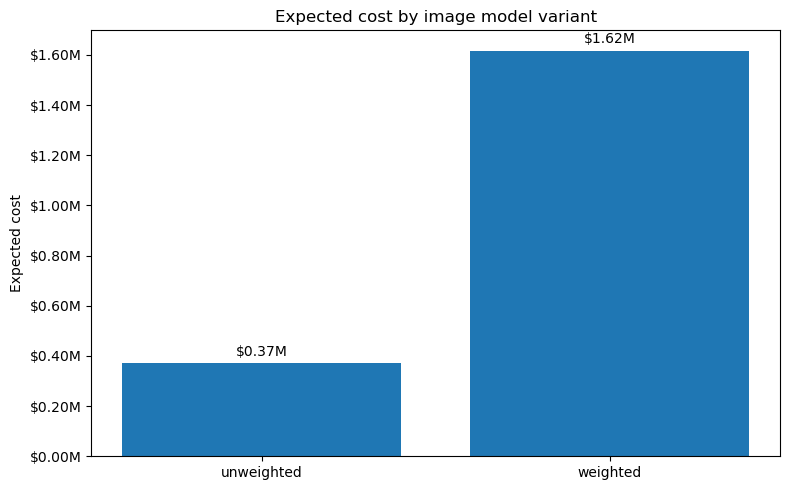

In [27]:
cost_plot_df = comparison_df.sort_values("tuned_expected_cost")

plt.figure(figsize=(8, 5))
bars = plt.bar(cost_plot_df["model"], cost_plot_df["tuned_expected_cost"])
plt.title("Expected cost by image model variant")
plt.ylabel("Expected cost")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
plt.bar_label(bars,
    labels=[f"${v/1_000_000:.2f}M" for v in cost_plot_df["tuned_expected_cost"]],
    padding=3)
plt.tight_layout()
plt.show()


The chart shows that the unweighted ResNet18 model has a much lower expected cost than the weighted model. Although the weighted model has slightly higher precision and F1-score, it misses more fraud cases, which increases cost. Therefore, the unweighted model is selected as the final image-only baseline.

## Threshold performance plot

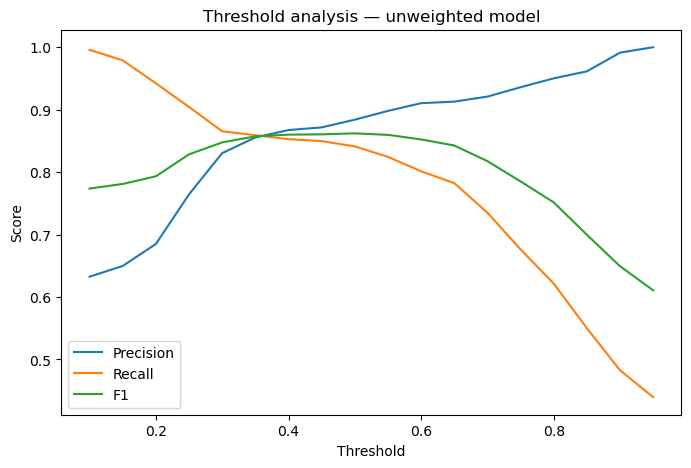

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results_unweighted["threshold"],
         threshold_results_unweighted["precision"], label="Precision")
plt.plot(threshold_results_unweighted["threshold"],
         threshold_results_unweighted["recall"],    label="Recall")
plt.plot(threshold_results_unweighted["threshold"],
         threshold_results_unweighted["f1"],        label="F1")
plt.title("Threshold analysis — unweighted model")
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.legend()
plt.show()


## Tuned confusion matrices

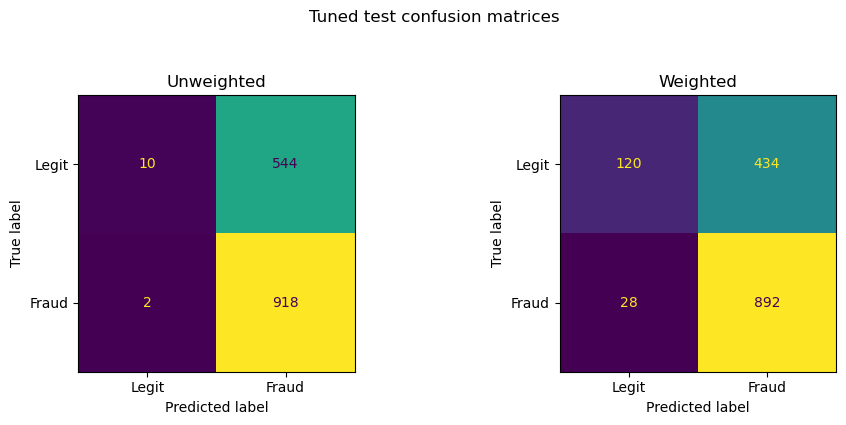

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (cm, title_) in zip(axes, [
    (tuned_cm_unweighted, "Unweighted"),
    (tuned_cm_weighted,   "Weighted"),
]):
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["Legit","Fraud"]).plot(
        ax=ax, colorbar=False, values_format="d")
    ax.set_title(title_)
plt.suptitle("Tuned test confusion matrices", y=1.05)
plt.tight_layout()
plt.show()


The tuned confusion matrices show why the unweighted ResNet18 model has the lower expected cost.

The unweighted model detects 918 out of 920 fraud cases and misses only 2. However, it also flags many legitimate cases as fraud, producing 544 false positives. The weighted model is more conservative: it produces fewer false positives, 434, but misses more fraud cases, 28.

Because false negatives are much more expensive than false positives in this experiment, the unweighted model is better from a cost-sensitive perspective. Even though it creates more false alarms, it misses far fewer fraud cases, which leads to the lower expected cost.

## Threshold analysis - precision, recall, F1

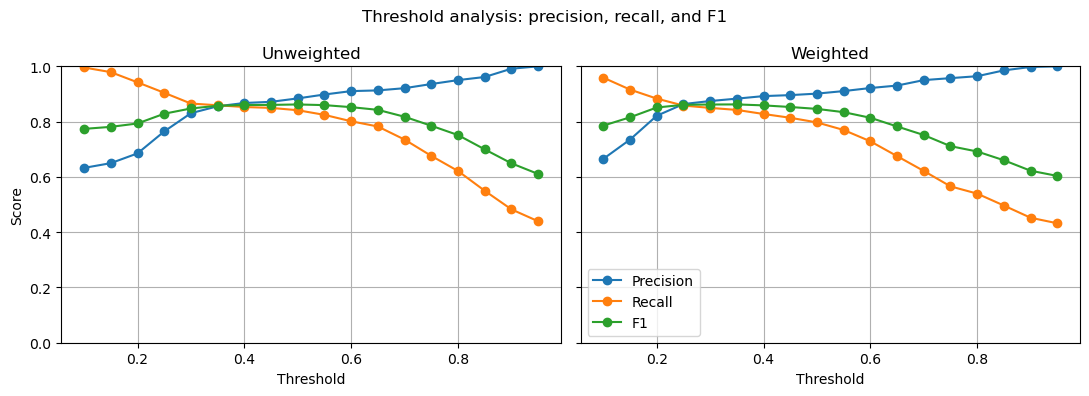

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (df, title_) in zip(axes, [
    (threshold_results_unweighted, "Unweighted"),
    (threshold_results_weighted,   "Weighted"),
]):
    ax.plot(df["threshold"], df["precision"], marker="o", label="Precision")
    ax.plot(df["threshold"], df["recall"],    marker="o", label="Recall")
    ax.plot(df["threshold"], df["f1"],        marker="o", label="F1")
    ax.set_title(title_); ax.set_xlabel("Threshold")
    ax.set_ylim(0, 1); ax.grid(True)
axes[0].set_ylabel("Score")
axes[-1].legend(loc="best")
plt.suptitle("Threshold analysis: precision, recall, and F1")
plt.tight_layout()
plt.show()


## Expected cost by threshold

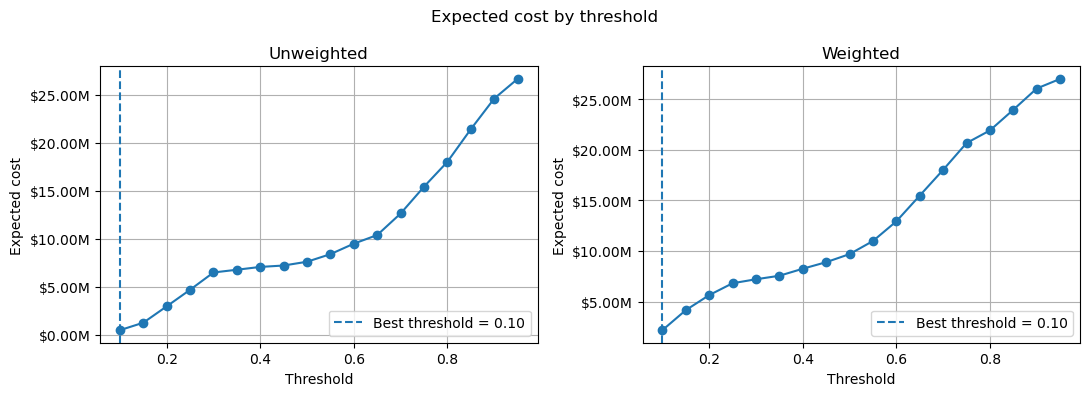

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
for ax, (df, title_) in zip(axes, [
    (cost_df_unweighted, "Unweighted"),
    (cost_df_weighted,   "Weighted"),
]):
    df_sorted = df.sort_values("threshold")
    best_row  = df.loc[df["expected_cost"].idxmin()]
    ax.plot(df_sorted["threshold"], df_sorted["expected_cost"], marker="o")
    ax.axvline(best_row["threshold"], linestyle="--",
               label=f"Best threshold = {best_row['threshold']:.2f}")
    ax.set_title(title_); ax.set_xlabel("Threshold")
    ax.set_ylabel("Expected cost")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
    ax.grid(True); ax.legend()
plt.suptitle("Expected cost by threshold")
plt.tight_layout()
plt.show()


## Precision-Recall curves

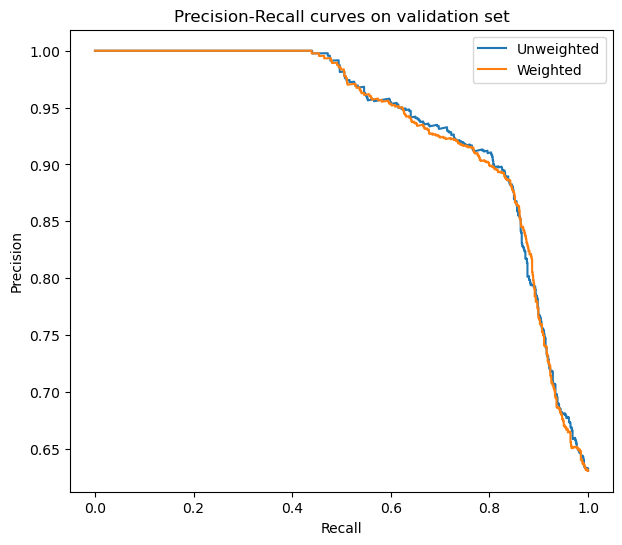

In [32]:
p_u, r_u, _ = precision_recall_curve(val_y_unweighted, val_p_unweighted)
p_w, r_w, _ = precision_recall_curve(val_y_weighted,   val_p_weighted)

plt.figure(figsize=(7, 6))
plt.plot(r_u, p_u, label="Unweighted")
plt.plot(r_w, p_w, label="Weighted")
plt.title("Precision-Recall curves on validation set")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.legend()
plt.show()


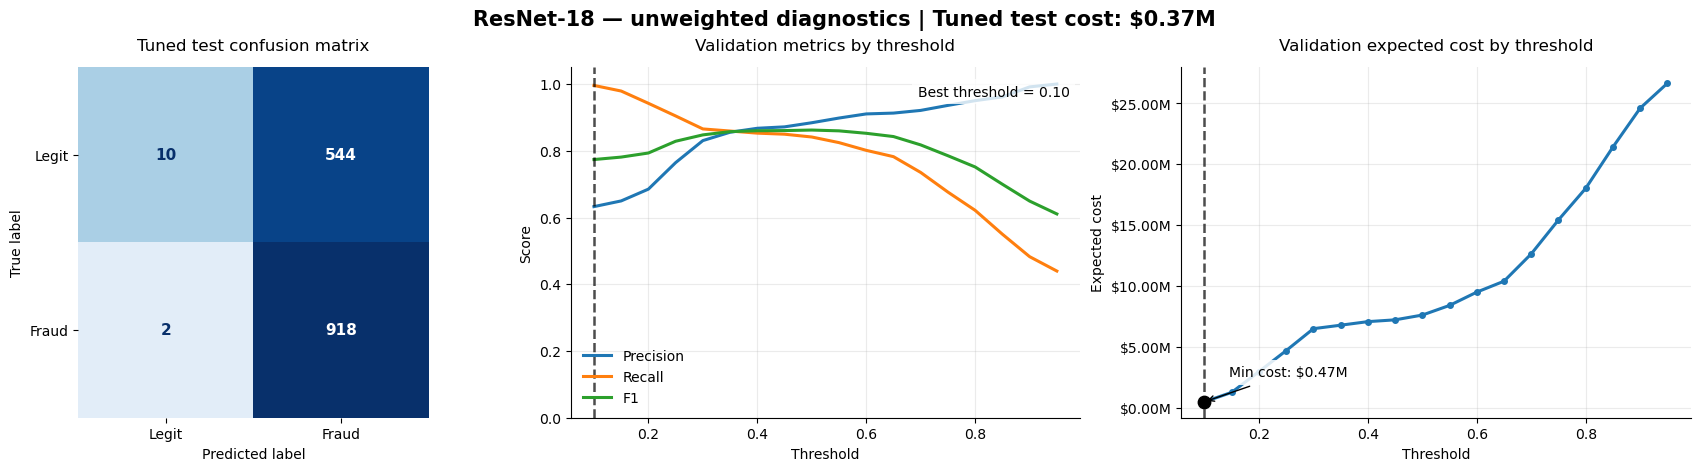

In [33]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_unweighted,
    threshold_results=threshold_results_unweighted,
    cost_df=cost_df_unweighted,
    model_name="ResNet-18 — unweighted",
    save_path=RESULTS_BASE / "diagnostics_unweighted.png",
)


The unweighted ResNet18 diagnostics show the final cost-tuned image-only baseline. The selected threshold is 0.10, which gives the lowest validation expected cost.

At this threshold, the model becomes very sensitive to fraud. On the test set, it detects 918 out of 920 fraud cases and misses only 2. This gives very high recall. However, it also produces 544 false positives, meaning that many legitimate cases are incorrectly flagged as fraud.

The cost curve explains why this low threshold was selected. Even though false positives increase, false negatives are much more expensive. Therefore, reducing missed fraud cases has a stronger effect on expected cost. The final test cost is $0.37M, which is lower than the weighted ResNet18 model.

Overall, the unweighted ResNet18 model is selected as the final image-only baseline because it achieves the lowest expected cost.

The confusion matrix shows the tuned test performance. Validation metrics and cost curves show how the threshold was selected for the unweighted model.

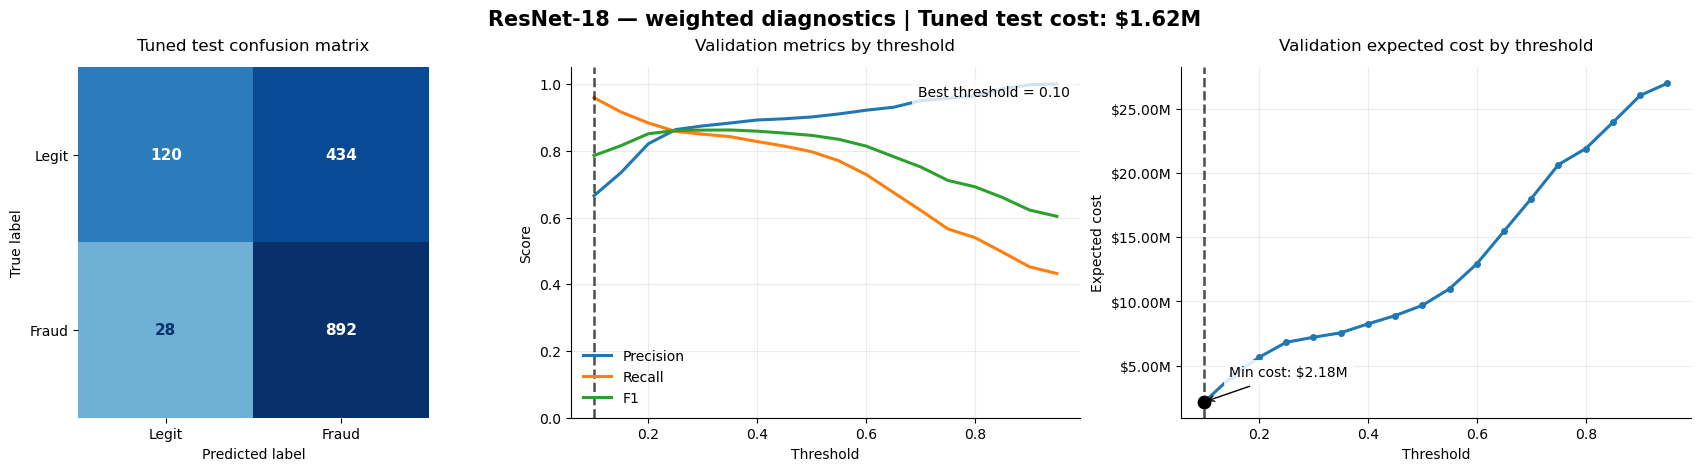

In [34]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_weighted,
    threshold_results=threshold_results_weighted,
    cost_df=cost_df_weighted,
    model_name="ResNet-18 — weighted",
    save_path=RESULTS_BASE / "diagnostics_weighted.png",
)


The weighted ResNet18 diagnostics show that this model is also tuned to threshold 0.10 based on validation expected cost.

At this threshold, the model detects 892 out of 920 fraud cases and misses 28. It also produces 434 false positives. Compared with the unweighted ResNet18 model, it creates fewer false positives, but it misses more fraud cases.

The cost curve explains why the weighted model performs worse from a cost-sensitive perspective. Since false negatives are much more expensive than false positives, the additional missed fraud cases increase the expected cost. The final test cost is $1.62M, which is higher than the unweighted model.

Overall, the weighted ResNet18 model is more conservative, but it is not the best image-only baseline because it misses more fraud cases and has a higher expected cost.

The confusion matrix shows the tuned test performance. Validation metrics and cost curves show how the threshold was selected for the weighted model.

## Final choice




In [35]:
comparison_df.to_csv(RESULTS_BASE / "comparison.csv", index=False)
print("Saved comparison to:", RESULTS_BASE / "comparison.csv")
final_choice_df = comparison_df.sort_values("tuned_expected_cost").copy()
final_choice_df


Saved comparison to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_image_resnet18\comparison.csv


,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,unweighted,0.862069,0.878486,0.936802,0.860045,0.885104,0.938443,0.1,0.627907,0.997826,0.770781,372000
1,weighted,0.845982,0.876130,0.935574,0.843149,0.880256,0.935706,0.1,0.672700,0.969565,0.794301,1617000
